# Customer Segmentation Project

## 1. Data Exploration

In this notebook, we will perform exploratory data analysis (EDA) on the customer dataset. The goal is to understand the data, identify patterns, and prepare for further analysis.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualisation style
sns.set(style='whitegrid')

## 2. Load the Data

We will load the customer data from the CSV file.

In [15]:
# Load the dataset (Online Retail from Kaggle)
data_path = '../data/raw/online_retail.csv'
customers = pd.read_csv(data_path, encoding='latin-1')

# Create TotalSpent column by multiplying Quantity and UnitPrice
if 'Quantity' in customers.columns and 'UnitPrice' in customers.columns:
    customers['TotalSpent'] = customers['Quantity'] * customers['UnitPrice']

# Display the first few rows of the dataset
customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpent
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


## 3. Basic Inspection

Let's inspect the dataset for basic information, including the shape, data types, and missing values.

In [13]:
# Display column names to understand the data structure
print("Column names:")
print(customers.columns.tolist())
print("\nData shape:", customers.shape)
print("\nData types:")
print(customers.dtypes)
print("\nMissing values:")
missing_values = customers.isnull().sum()
print(missing_values[missing_values > 0])

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalSpent']

Data shape: (541909, 9)

Data types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
TotalSpent     float64
dtype: object

Missing values:
Description      1454
CustomerID     135080
dtype: int64


## 4. Exploratory Plots

We will create some exploratory plots to visualize the distribution of key features.

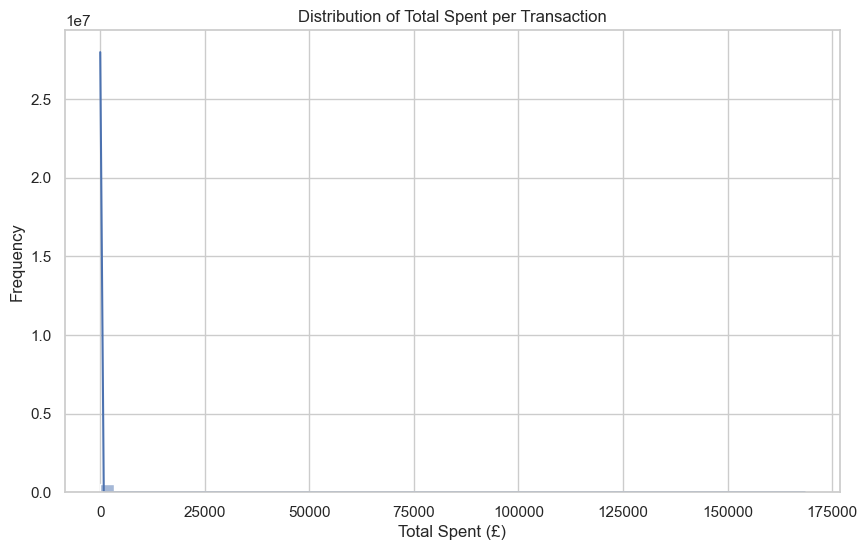

In [16]:
# Distribution of TotalSpent (calculated from Quantity * UnitPrice)
# Remove any NaN or negative values for cleaner visualization
total_spent_clean = customers['TotalSpent'].dropna()
total_spent_clean = total_spent_clean[total_spent_clean > 0]

plt.figure(figsize=(10, 6))
sns.histplot(total_spent_clean, bins=50, kde=True)
plt.title('Distribution of Total Spent per Transaction')
plt.xlabel('Total Spent (£)')
plt.ylabel('Frequency')
plt.show()

## 5. Summary of Findings

In this section, we will summarize the key findings from our exploratory data analysis.

In [10]:
# Summary statistics
summary_stats = customers.describe()
summary_stats

,customer_id,postcode,age,total_spent
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,68231.000000,36.000000,2380.275000
std,3.02765,30063.896768,7.745967,799.538821
min,1.00000,10001.000000,27.000000,1500.500000
25%,3.25000,64251.000000,29.500000,1825.312500
50%,5.50000,77601.000000,35.000000,2150.000000
75%,7.75000,88751.000000,41.000000,2875.187500
max,10.00000,95101.000000,50.000000,4000.000000
